In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4
Running on PyMC3 v3.11.4


In [6]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


,Unnamed: 0,participant,index,session,draws,acc,confidence_BT,gender,age,pdi,caps,pdi_group,caps_group
0,0,AD20,5,1.0,1.0,1.0,3.019048,0.0,18.0,71.0,154.0,high_pdi,high_caps
1,1,AD20,6,1.0,3.0,1.0,5.952381,0.0,18.0,71.0,154.0,high_pdi,high_caps
2,2,AD20,7,1.0,5.0,1.0,4.980952,0.0,18.0,71.0,154.0,high_pdi,high_caps
3,3,AD20,8,1.0,3.0,1.0,6.980952,0.0,18.0,71.0,154.0,high_pdi,high_caps
4,4,AD20,9,1.0,6.0,1.0,5.971429,0.0,18.0,71.0,154.0,high_pdi,high_caps


In [2]:
data = pd.read_csv("data_bt_dem.csv")
participantcode = data.participant.unique()
data["confidence_BT"] = data["confidence_BT"]*0.1
data["confidence_BT"] = data["confidence_BT"].astype(theano.config.floatX)

In [10]:
fig = px.violin(data, y='confidence_BT',x="session",
                   orientation='v',
                   labels={'confidence_BT': 'conf',
                            'acc': 'Response'},
                   width=1733,
                   height=900)

fig.show()

In [11]:
fig = px.histogram(data, x="confidence_BT",
                   histnorm='probability density',
                   orientation='v',
                   labels={'draws': 'conf',
                            'acc': 'Response'},
                   barmode='overlay',
                   width=1733,
                   height=900)

fig.show()

In [4]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_conf=data["confidence_BT"].mean()
sd_conf=data["confidence_BT"].std()

median_conf=data["confidence_BT"].median()
hr_conf= pm.Model(coords=coords) 

with hr_conf:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=0, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", 5,testval=100)
    mu_beta_tms = pm.Normal("mu_beta_tms", mu=0, sigma=5)
    sigma_b = pm.HalfNormal("sigma_b", 5,testval=100)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b = pm.Normal("b", mu=mu_beta_tms, sigma=sigma_b, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5)
    confidence_BT_est = a[participant_idx] + b[participant_idx] * data.session.values

    # Data likelihood
    confidence_BT_like = pm.Normal(
        "confidence_BT_like", mu=confidence_BT_est,sigma=eps, observed=data.confidence_BT, dims="obs_id")
    
    

In [5]:
with hr_conf:
    hr_conf_trace = pm.sample(10000,tune=10000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b, a, sigma_b, mu_beta_tms, sigma_a, mu_a]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 288 seconds.


0, dim: obs_id, 1357 =? 1357


There were 302 divergences after tuning. Increase `target_accept` or reparameterize.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
There were 73 divergences after tuning. Increase `target_accept` or reparameterize.
There were 116 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.


In [6]:
import pickle
# Save the model
with open('hr_conf_bt_tms.pkl', 'wb') as file:
    pickle.dump(hr_conf, file)
    
hr_conf_trace.to_netcdf('hr_conf_bt_tms_trace.nc', compress=False)

'hr_conf_bt_tms_trace.nc'

In [3]:
import pickle

# Load the model from the pickled file
with open('hr_conf_bt_tms.pkl', 'rb') as file:
    hr_conf = pickle.load(file)

hr_conf_trace = az.from_netcdf('hr_conf_bt_tms_trace.nc')


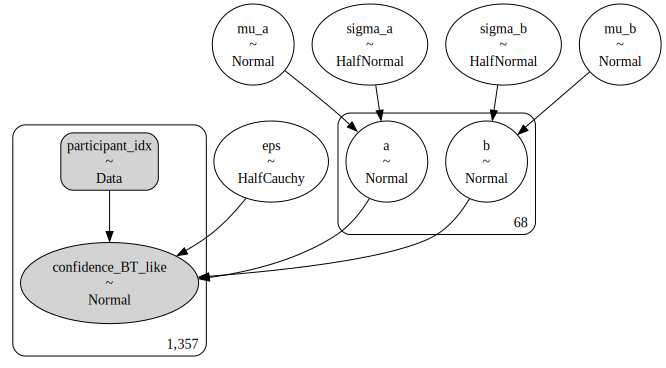

In [38]:
pm.model_to_graphviz(hr_conf)

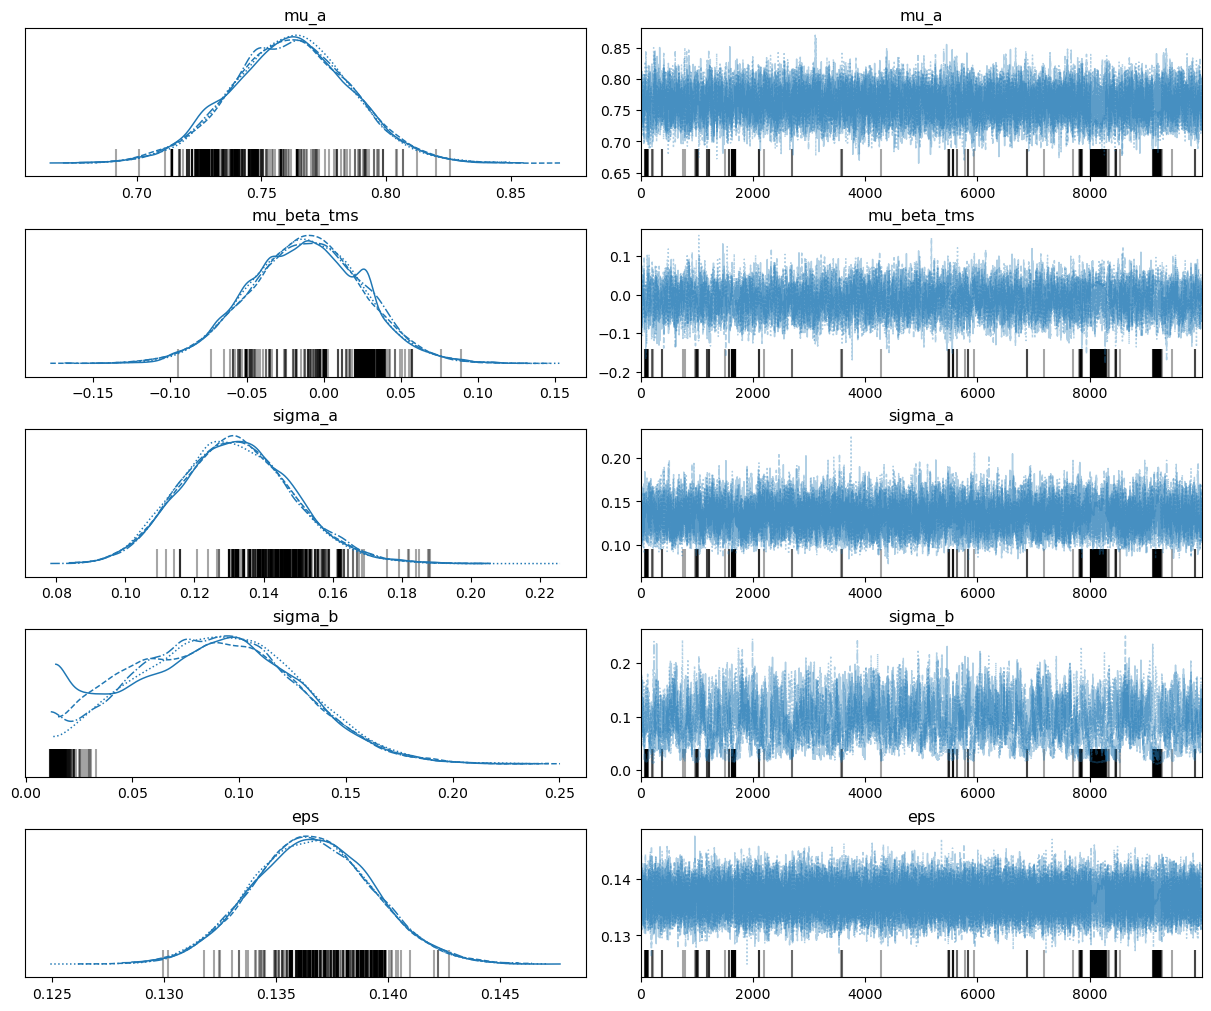

In [8]:
az.plot_trace(hr_conf_trace, var_names=["mu_a", "mu_beta_tms", "sigma_a", "sigma_b", "eps"]);


In [40]:
stat_tms_reg=pm.summary(hr_conf_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.762,0.024,0.716,0.806,0.000,0.000,2537.0,5480.0,1.00
mu_b,-0.013,0.037,-0.081,0.057,0.001,0.001,1679.0,3589.0,1.00
a[0],0.676,0.083,0.522,0.836,0.001,0.001,3305.0,8465.0,1.00
a[1],0.655,0.085,0.503,0.820,0.002,0.001,2919.0,7455.0,1.00
a[2],0.806,0.082,0.652,0.962,0.002,0.001,2554.0,825.0,1.00
...,...,...,...,...,...,...,...,...,...
b[66],0.007,0.079,-0.134,0.167,0.001,0.001,5048.0,9150.0,1.00
b[67],-0.013,0.101,-0.204,0.189,0.001,0.001,8769.0,6995.0,1.00
sigma_a,0.133,0.017,0.104,0.166,0.001,0.000,1017.0,758.0,1.00
sigma_b,0.087,0.040,0.011,0.149,0.002,0.002,245.0,218.0,1.01


In [9]:
with hr_conf:
    posterior_pred = pm.sample_posterior_predictive(
        hr_conf_trace, var_names=["a", "b","confidence_BT_like"]
    )

In [12]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_conf_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_conf_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_conf_trace).waic

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



Log likelihood: <xarray.DataArray 'draw' ()>
array(4999.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset>
Dimensions:             ()
Data variables:
    confidence_BT_like  float64 3.106e+07
Effective number of parameters (p_waic): 66.4525435033607
WAIC: 741.7183447187826


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



In [10]:
observed_data = data['confidence_BT']  # Replace with your actual observed data
predicted_data=np.abs(posterior_pred['confidence_BT_like'])
deviances = -2 * np.sum(np.log(predicted_data), axis=1)

pD = np.mean(deviances) - deviances.mean()
DIC = pD + np.mean(deviances)
print (DIC)

876.8664849069262


<Axes: xlabel='confidence_like'>

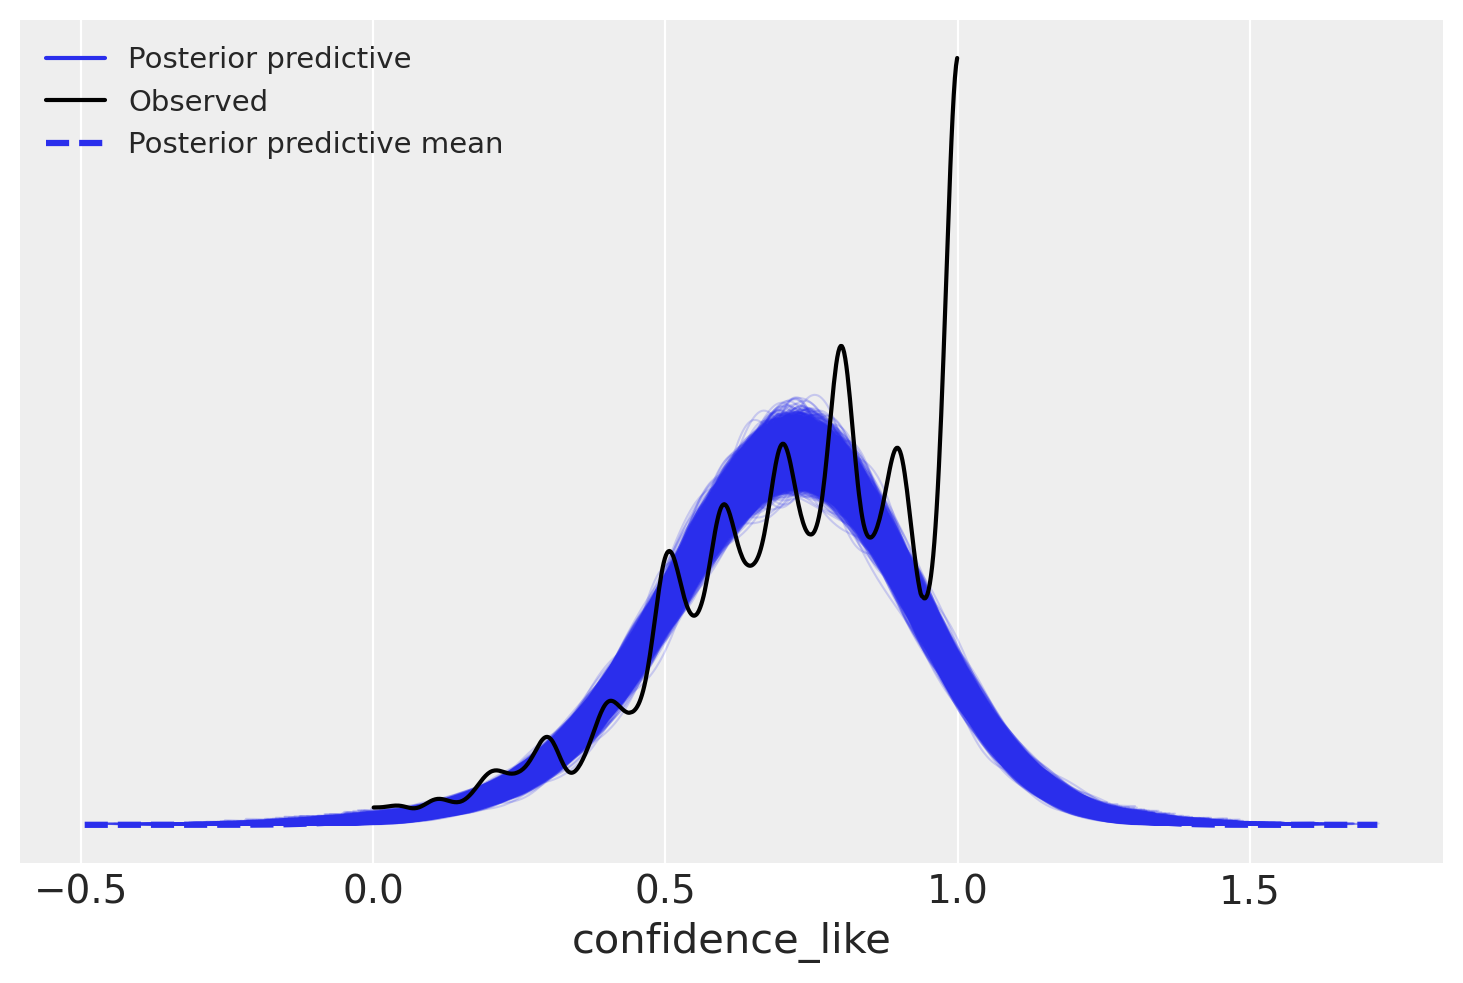

In [68]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_conf))

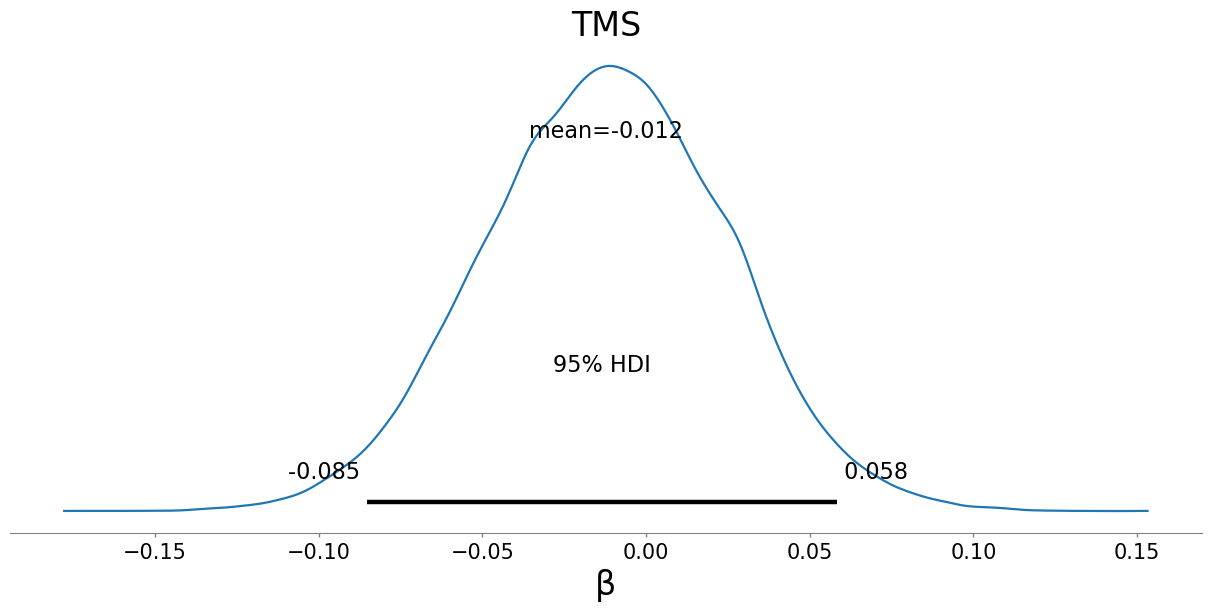

<Figure size 1200x600 with 0 Axes>

In [14]:
plot = az.plot_posterior(hr_conf_trace, var_names=["mu_beta_tms"],
                         textsize=15,
                         hdi_prob=0.95,
                         figsize=(12, 6))

# Set the DPI for high resolution
dpi = 300

# Get the axes from the plot
axes = plot

# Create a new Figure and specify the spacing between subplots
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 1)  # Only one subplot in this case

# Add the existing axis to the new Figure
ax = axes  # Use the existing axes

# Customize the x-axis label
ax.set_xlabel("β", fontsize=24)

# Set the title for the subplot
title = "TMS"

# Set the title for the subplot
ax.set_title(title, fontsize=24)

# Save the image with high resolution
fig.savefig("suppl_study2_mu_BT_tms_traces.png", dpi=dpi)

# Display the plot
plt.show()
